<a href="https://colab.research.google.com/github/rypriyanka2005/Machine-Learning-Sem-4/blob/MLlabs/MLLAB6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Entropy: 2.8079550345752406
Gini Index: 0.8175817154950598
Information Gain per feature:
Feature_1: 0.0267
Feature_2: 0.0000
Feature_3: 0.0000
Feature_4: 0.0000
Feature_5: 0.0058
Feature_6: 0.0000
Feature_7: 0.0000
Feature_8: 0.0113
Feature_9: 0.0000
Feature_10: 0.0162
Feature_11: 0.0000
Feature_12: 0.0000
Feature_13: 0.0000
Feature_14: 0.0000
Feature_15: 2.8080
Feature_16: 2.8080
Feature_17: 0.0000
Feature_18: 0.0000
Feature_19: 0.0000
Feature_20: 0.0000
Feature_21: 0.0000
Feature_22: 0.0000
Feature_23: 0.0106
Feature_24: 0.0000
Feature_25: 0.0000
Feature_26: 0.0000
Feature_27: 0.0000
Feature_28: 0.0261
Feature_29: 0.0000
Feature_30: 0.0000
Feature_31: 0.0000
Feature_32: 0.0894
Feature_33: 0.0000
Feature_34: 0.0000
Feature_35: 0.0000
Feature_36: 0.0000
Feature_37: 0.0261
Feature_38: 0.0000
Feature_39: 0.0000
Feature_40: 0.0000
Feature_41: 0.0255
Feature_42: 0.0000
Feature_43: 0.0143
Feature_44: 0.0000
Feature_45: 0.0000
Feature_46: 0.0000
Feature_47: 0.0187
Feature_48: 0.0000
Feature_

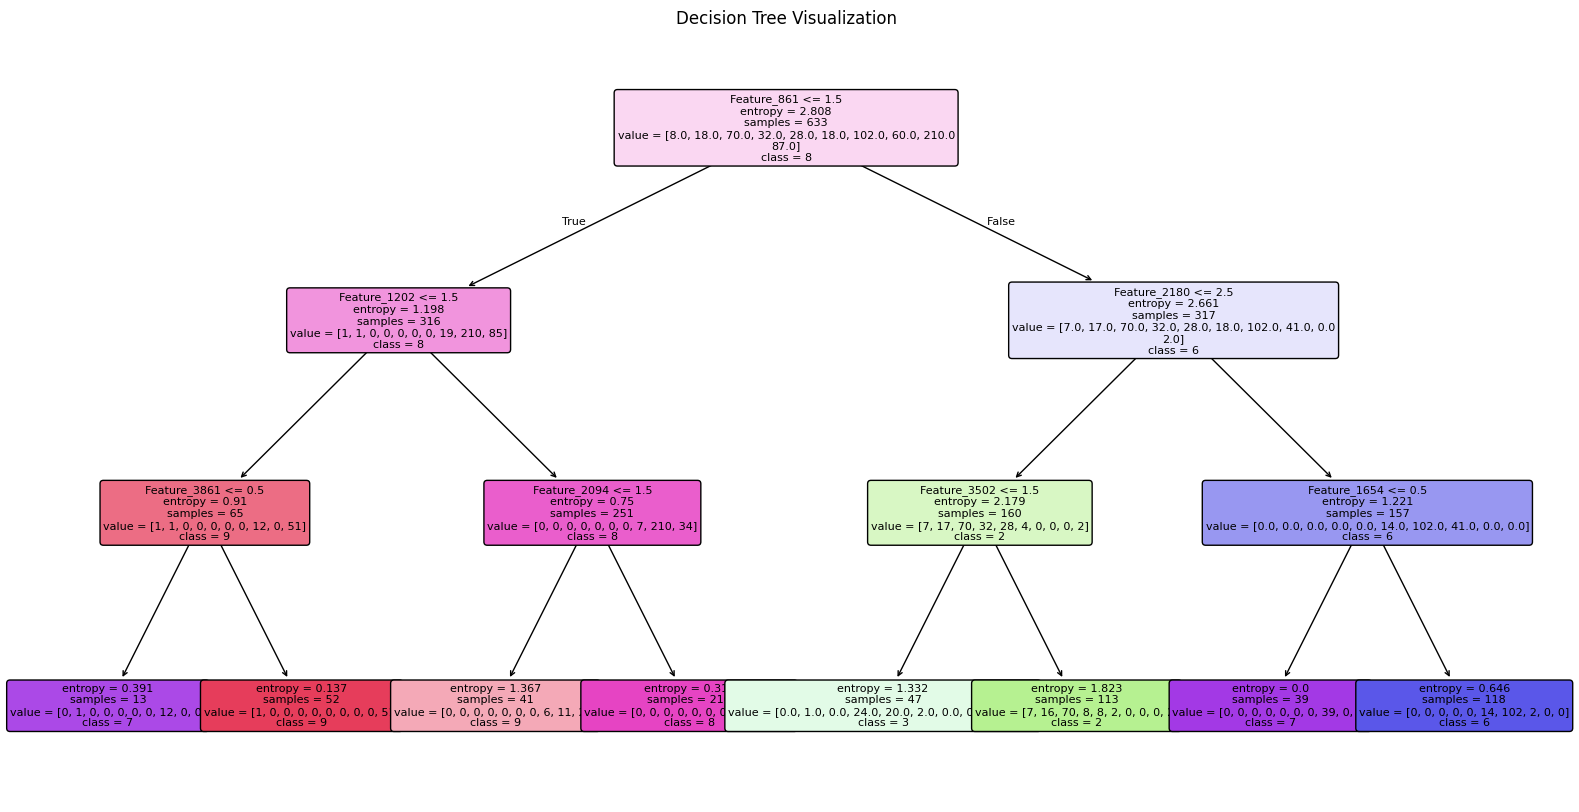

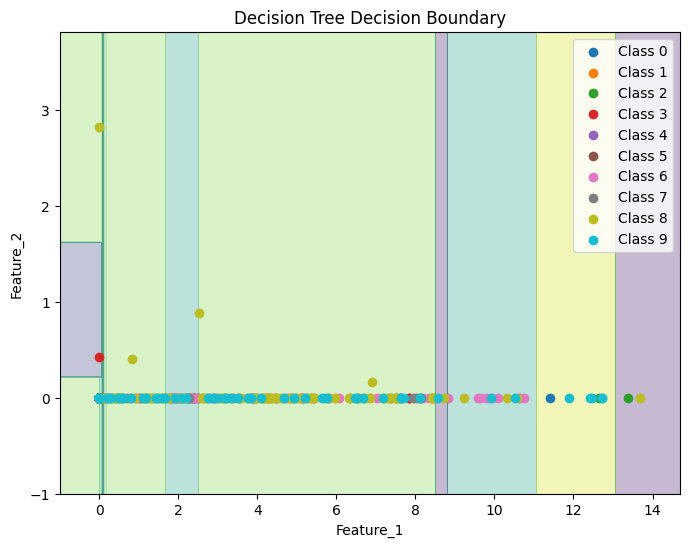

In [27]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier


df = pd.read_excel("/content/Stereotype ml dataset.xlsx", engine="openpyxl")
features = df.drop(columns=["Label"])
features = features.select_dtypes(include=["int64", "float64"])
X = features
#or X = df.drop("Label")
y = df["Label"].values

#A1

'''only for continous nemeric values
def equal_width_binning(y, bins=4):
    """
    Performs equal width binning on continuous target variable.
    Returns binned categorical values.
    """
    y = np.array(y)
    # Find min and max
    min_val = np.min(y)
    max_val = np.max(y)
    # Compute bin width
    width = (max_val - min_val) / bins
    # Create bin edges
    bin_edges = [min_val + i * width for i in range(bins + 1)]
    # Perform binning
    binned = pd.cut(y, bins=bin_edges, include_lowest=True, labels=False)
    return binned
'''

def calculate_entropy(y):
    values, counts = np.unique(y, return_counts=True)
    probabilities = counts / counts.sum()

    entropy = -np.sum(probabilities * np.log2(probabilities))
    return entropy

'''only for continous nemeric values
# Step 1: Convert to 4 bins
#y_binned = equal_width_binning(y, bins=4)

'''
#  Calculate entropy
entropy_value = calculate_entropy(y)
print("Entropy:", entropy_value)



#A2


def calculate_gini(y):
    values, counts = np.unique(y, return_counts=True)
    probabilities = counts / counts.sum()

    gini = 1 - np.sum(probabilities ** 2)
    return gini

gini_value = calculate_gini(y)
print("Gini Index:", gini_value)


#A3

def bin_feature(feature, bins=4, method="equal_width"):
    feature = np.array(feature)

    if method == "equal_width":
        min_val = np.min(feature)
        max_val = np.max(feature)
        width = (max_val - min_val) / bins
        bin_edges = [min_val + i * width for i in range(bins + 1)]
        return pd.cut(feature, bins=bin_edges, include_lowest=True, labels=False)

    elif method == "equal_frequency":
      # not manual we are using pd function
        return pd.qcut(feature, q=bins, labels=False, duplicates="drop")

    else:
        raise ValueError("Method must be 'equal_width' or 'equal_frequency'")
def information_gain(X, y, feature):
    # Total entropy before split
    total_entropy = calculate_entropy(y)

    values, counts = np.unique(X[feature], return_counts=True)

    weighted_entropy = 0

    for v, count in zip(values, counts):
        y_subset = y[X[feature] == v]
        weighted_entropy += (count / len(y)) * calculate_entropy(y_subset)

    return total_entropy - weighted_entropy

def find_root_feature(X, y, bins=4, method="equal_width"):

    X_binned = X.copy()

    # Convert continuous features to categorical
    for column in X.columns:
        if np.issubdtype(X[column].dtype, np.number):
            X_binned[column] = bin_feature(X[column], bins=bins, method=method)

    gains = {}

    for feature in X_binned.columns:
        gains[feature] = information_gain(X_binned, y, feature)

    root_feature = max(gains, key=gains.get)

    return root_feature, gains

    return root, gains

root, gains = find_root_feature(X, y, bins=4, method="equal_frequency")

print("Information Gain per feature:")
for f, g in gains.items():
    print(f"{f}: {g:.4f}")

print("\nRoot Node:", root)


#A4

# our own bin function

def bin_feature(feature, bins=4, method="equal_width"):
    """
    Converts a continuous feature into categorical bins.

    Parameters:
    feature : array-like Continuous values
    bins : int, optional (default=4)
        Number of bins
    method : str, optional (default="equal_width")
        "equal_width" or "equal_frequency"

    Returns:
    --------
    binned_feature : numpy array
        Bin labels (0,1,2,...)
    """

    feature = np.array(feature)

    if method == "equal_width":
        min_val = np.min(feature)
        max_val = np.max(feature)

        width = (max_val - min_val) / bins
        bin_edges = [min_val + i * width for i in range(bins + 1)]

        # Assign bins manually
        binned = np.digitize(feature, bin_edges, right=False) - 1

        # Fix edge case for max value
        binned[binned == bins] = bins - 1

    elif method == "equal_frequency":
        sorted_indices = np.argsort(feature)
        binned = np.zeros(len(feature))

        bin_size = len(feature) // bins

        for i in range(bins):
            start = i * bin_size
            end = (i + 1) * bin_size if i != bins - 1 else len(feature)
            indices = sorted_indices[start:end]
            binned[indices] = i

    else:
        raise ValueError("Method must be 'equal_width' or 'equal_frequency'")

    return binned.astype(int)

binned_A3 = bin_feature(X['Feature_4088'])


#A5
## our own decision tree function

def information_gain(X, y, feature_index):

    # total entropy before split
    total_entropy = calculate_entropy(y)

    # column values
    feature_values = X[:, feature_index]

    values, counts = np.unique(feature_values, return_counts=True)

    weighted_entropy = 0

    for v, count in zip(values, counts):

        # boolean mask
        mask = feature_values == v

        y_subset = y[mask]

        weighted_entropy += (count / len(y)) * calculate_entropy(y_subset)

    return total_entropy - weighted_entropy
def best_feature(X, y):

    gains = []

    for feature_index in range(X.shape[1]):
        gain = information_gain(X, y, feature_index)
        gains.append(gain)

    return np.argmax(gains)

def build_tree(X, y):

    # If pure node → return class label
    if len(np.unique(y)) == 1:
        return y[0]

    # If no features left
    if X.shape[1] == 0:
        return np.bincount(y).argmax()

    feature_index = best_feature(X, y)

    tree = {
        "feature": feature_index,
        "children": {}
    }

    feature_values = X[:, feature_index]
    unique_values = np.unique(feature_values)

    for value in unique_values:

        subset_mask = (feature_values == value)
        subset_X = X[subset_mask]
        subset_y = y[subset_mask]

        # Remove used feature column
        subset_X = np.delete(subset_X, feature_index, axis=1)

        subtree = build_tree(subset_X, subset_y)

        tree["children"][value] = subtree

    return tree

def predict(tree, x):

    # If leaf node
    if not isinstance(tree, dict):
        return tree

    feature_index = tree["feature"]
    value = x[feature_index]

    if value in tree["children"]:
        subtree = tree["children"][value]

        # Remove feature
        x_new = np.delete(x, feature_index)

        return predict(subtree, x_new)

    else:
        return None


# STEP 1 — Bin Your Continuous Features FIRST
X_binned = X.copy()

for col in X.columns:
    X_binned[col] = bin_feature(X[col], bins=4, method="equal_frequency")

X_array = X_binned.values

tree_model = build_tree(X_array, y)
prediction = predict(tree_model, X_array[0])
print(tree_model)
print("Prediction:", prediction)


#A6
clf = DecisionTreeClassifier(
    criterion="entropy",   # matches information gain
    max_depth=3,           # keep tree readable
    random_state=42
)

clf.fit(X_binned, y)

plt.figure(figsize=(20,10))

tree.plot_tree(clf,feature_names=X_binned.columns,class_names=[str(c) for c in clf.classes_],filled=True,rounded=True,fontsize=8)

plt.title("Decision Tree Visualization")
plt.show()



#Q7

def plot_decision_boundary(model, X, y, feature_names=None, resolution=0.01):
    """
    model : trained sklearn classifier
    X     : 2D feature array (n_samples, 2)
    y     : target labels
    feature_names : optional list of 2 feature names
    resolution : grid step size
    """

    if X.shape[1] != 2:
        raise ValueError("X must contain exactly 2 features.")

    # Define min and max values
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Create mesh grid
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, resolution),
        np.arange(y_min, y_max, resolution)
    )

    # Predict on grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    plt.figure(figsize=(8,6))
    plt.contourf(xx, yy, Z, alpha=0.3)

    # Plot data points
    for label in np.unique(y):
        plt.scatter(
            X[y == label, 0],
            X[y == label, 1],
            label=f"Class {label}"
        )

    # Labels
    if feature_names:
        plt.xlabel(feature_names[0])
        plt.ylabel(feature_names[1])

    plt.title("Decision Tree Decision Boundary")
    plt.legend()
    plt.show()


feat1 = "Feature_1" # Changed 'Feature_0' to 'Feature_1'
feat2 = "Feature_2"

X2 = X[[feat1, feat2]].values
y2 = df["Label"].values

clf = DecisionTreeClassifier(criterion="entropy",max_depth=4,random_state=4)

clf.fit(X2, y2)

plot_decision_boundary(clf,X2,y2,feature_names=[feat1, feat2])